# Production Loss Assessment & Downtime Optimization in the Volve Field

**A Production Engineering analysis of well uptime, downtime, and production-loss opportunity**

This notebook analyzes daily production data from the Volve field (Norwegian North Sea,
producing 2008-2016, publicly released by Equinor and the Volve licence partners, which
include ExxonMobil Exploration & Production Norway AS) from a **production engineering and
operations** perspective. It is not a reservoir-simulation, decline-curve-forecasting, or
machine-learning project. The goal is to answer the question a production engineer is
actually asked day to day:

> **Where is production being lost, and which wells should be prioritized for production
> recovery efforts?**

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)

DATA_PATH = '../data/Volve production data.xlsx'

## 1. Business Understanding

**What Production Engineers do.** A production engineer is responsible for maximizing the
amount of oil and gas a field delivers safely and economically from wells that already
exist. That means monitoring how each well is performing day to day, understanding when and
why a well stops flowing, diagnosing whether reduced output is caused by the reservoir,
mechanical equipment, surface facilities, or an operational decision (a planned shut-in), and
recommending where engineering attention should go first.

**Why uptime matters.** A well can only produce oil while it is flowing — hours it is shut in,
choked back for a facility constraint, or offline for a mechanical problem are hours of lost
opportunity. `ON_STREAM_HRS` (hours per day a well was flowing) is the single most direct
signal of whether a well is doing its job.

**Why downtime matters.** Downtime is not automatically a problem — some of it is planned
(scheduled maintenance, well tests, platform-wide shutdowns) and some is unplanned (equipment
failure, sand production, reservoir-related issues). But downtime is where production
engineers spend most of their investigative time, because unplanned downtime is the downtime
that is recoverable through engineering action.

**Why production losses matter.** Every barrel a well *could* have produced but did not,
represents deferred revenue that a field's economics were built around. Quantifying that gap
— even approximately — is what lets an engineering team prioritize scarce time and workover
budget toward the wells where recovering uptime pays off the most.

**Why production recovery is important.** Recovering even a few percentage points of uptime
on a high-rate well is often cheaper and faster than any reservoir-side intervention, and it
is usually the first lever a production engineer is expected to pull before escalating to
well work, artificial-lift changes, or reservoir management.

### Production Engineering Interpretation
This project frames Volve's daily production data as an **operations performance problem**,
not a reservoir problem. Every metric that follows — uptime, downtime, estimated lost
production, and efficiency — exists to answer one operational question: *which wells are
losing the most opportunity, and where should a production engineer look first?* A production
engineer uses this kind of screening to build the shortlist that then gets handed to well
integrity, surveillance, or facilities teams for root-cause investigation — this notebook
stops at prioritization, which is the correct and defensible scope for a screening-level
analysis.

## 2. Data Understanding

The Volve daily production dataset records one row per well per day. The columns relevant to
this operational analysis are:

| Column | Meaning |
|---|---|
| `DATEPRD` | Production date |
| `WELL_BORE_CODE` | Well identifier |
| `FLOW_KIND` | `production` or `injection` — this project analyzes **producers only** |
| `WELL_TYPE` | `OP` (oil producer) or `WI` (water injector) |
| `ON_STREAM_HRS` | Hours in the day the well was actually flowing (0-24) |
| `BORE_OIL_VOL` | Oil volume produced that day (barrels) |
| `BORE_GAS_VOL` | Gas volume produced that day (Sm³) |
| `BORE_WAT_VOL` | Water volume produced that day (barrels) |

**`ON_STREAM_HRS`** is the operational backbone of this project. It is reported by the
facility's production accounting system and represents how many of the day's 24 hours the
well was actually on stream (flowing to the process facility). A well can be mechanically
capable of flowing and still show reduced `ON_STREAM_HRS` because of a planned test, a choke
change, a platform-wide process upset, or a genuine well problem — the dataset alone cannot
distinguish these causes, which is a limitation this project states explicitly rather than
guessing at.

**`BORE_OIL_VOL`, `BORE_GAS_VOL`, `BORE_WAT_VOL`** are the daily produced volumes measured at
the wellhead/facility. Oil volume is the primary economic output; gas and water are tracked
here only as context (water volume matters for water-cut and handling capacity, but is out of
scope for an uptime/downtime-focused screening).

### Production Engineering Interpretation
`ON_STREAM_HRS` and `BORE_OIL_VOL` together are enough to build every metric a production
engineer needs for a first-pass operational screening: uptime (is the well online?),
downtime (how many hours were lost?), and an estimate of the production opportunity those
lost hours represent. Pressure, choke, and temperature columns exist in the raw dataset but
are deliberately excluded here — they answer *why* a well underperforms, which is a follow-up
diagnostic question, not the prioritization question this notebook is built to answer.

## 3. Data Cleaning

We restrict the dataset to **oil producer wells** (`FLOW_KIND == 'production'` and
`WELL_TYPE == 'OP'`), which excludes the water-injector wellbore from the operational
screening — injection wells don't produce oil and are outside this project's scope.

In [2]:
df = pd.read_excel(DATA_PATH, sheet_name='Daily Production Data')

producers = df[(df['FLOW_KIND'] == 'production') & (df['WELL_TYPE'] == 'OP')].copy()
producers = producers[['DATEPRD', 'WELL_BORE_CODE', 'ON_STREAM_HRS',
                        'BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL']].copy()

print(f"Raw rows (all flow kinds/well types): {len(df):,}")
print(f"Producer rows: {len(producers):,}  |  Producer wells: {producers['WELL_BORE_CODE'].nunique()}")
print()
print(producers['WELL_BORE_CODE'].value_counts())

Raw rows (all flow kinds/well types): 15,634
Producer rows: 9,143  |  Producer wells: 6

WELL_BORE_CODE
NO 15/9-F-12 H    3056
NO 15/9-F-14 H    3056
NO 15/9-F-11 H    1165
NO 15/9-F-15 D     978
NO 15/9-F-1 C      744
NO 15/9-F-5 AH     144
Name: count, dtype: int64


**Missing-value assessment.** Within the producer subset, `ON_STREAM_HRS` and `BORE_OIL_VOL`
have no missing values — every producer-day row has both fields populated, so no imputation
is required for the core uptime/downtime metrics this project depends on.

In [3]:
missing = producers[['ON_STREAM_HRS', 'BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL']].isna().sum()
print("Missing values (producer rows only):")
print(missing)

Missing values (producer rows only):
ON_STREAM_HRS    0
BORE_OIL_VOL     0
BORE_GAS_VOL     0
BORE_WAT_VOL     0
dtype: int64


**Invalid-value assessment.** Two issues surface on inspection:

1. **`ON_STREAM_HRS` slightly above 24** on 13 rows. Checking the dates shows every one of
   these falls on **October 25-31** — the day European clocks fall back for daylight saving
   time, which legitimately adds a 25th hour to that calendar day. This is **not a data
   error**; it is a real operational artifact of the reporting calendar. To keep the daily
   uptime-percentage metric consistent (percent of a 24-hour day), these 13 values are capped
   at 24 hours rather than dropped — capping preserves the row and its oil volume while
   avoiding a >100% uptime figure.
2. **One row** (`NO 15/9-F-11 H`, 2015-01-17) reports `ON_STREAM_HRS = 0` while
   `BORE_OIL_VOL > 0` — a well can't produce oil with zero recorded on-stream hours, so this
   is a genuine data-quality inconsistency. Rather than deleting the row (it still carries a
   real oil volume that belongs in field totals), it is **flagged and excluded only from
   calculations that divide by `ON_STREAM_HRS`** (production-rate and loss-estimation
   metrics in Sections 6-7), where a zero denominator would be undefined.

**Duplicate check.** No duplicate `(DATEPRD, WELL_BORE_CODE)` combinations exist — each
well-day appears exactly once, so no de-duplication is needed.

In [4]:
# --- Fix 1: cap DST-related >24hr rows at 24 ---
n_dst = (producers['ON_STREAM_HRS'] > 24).sum()
dst_rows = producers.loc[producers['ON_STREAM_HRS'] > 24, ['DATEPRD', 'WELL_BORE_CODE', 'ON_STREAM_HRS']]
print(f"Rows with ON_STREAM_HRS > 24 (all on DST fall-back dates): {n_dst}")
print(dst_rows.to_string(index=False))

producers['ON_STREAM_HRS'] = producers['ON_STREAM_HRS'].clip(upper=24)

# --- Fix 2: flag (don't drop) the zero-hours-but-producing anomaly ---
anomaly_mask = (producers['ON_STREAM_HRS'] == 0) & (producers['BORE_OIL_VOL'] > 0)
print(f"\nZero-uptime-but-producing anomaly rows flagged: {anomaly_mask.sum()}")
print(producers.loc[anomaly_mask, ['DATEPRD', 'WELL_BORE_CODE', 'ON_STREAM_HRS', 'BORE_OIL_VOL']])

# --- Duplicate check ---
n_dupes = producers.duplicated(subset=['DATEPRD', 'WELL_BORE_CODE']).sum()
print(f"\nDuplicate (date, well) rows: {n_dupes}")

clean = producers.copy()
clean['UPTIME_PCT'] = clean['ON_STREAM_HRS'] / 24 * 100
clean['DOWNTIME_HRS'] = 24 - clean['ON_STREAM_HRS']
clean['YEAR'] = clean['DATEPRD'].dt.year

print(f"\nFinal clean dataset: {len(clean):,} rows | {clean['WELL_BORE_CODE'].nunique()} wells")
print(f"Date range: {clean['DATEPRD'].min().date()} to {clean['DATEPRD'].max().date()}")

Rows with ON_STREAM_HRS > 24 (all on DST fall-back dates): 13
   DATEPRD WELL_BORE_CODE  ON_STREAM_HRS
2014-10-26  NO 15/9-F-1 C       25.00000
2013-10-27 NO 15/9-F-11 H       24.30839
2014-10-26 NO 15/9-F-11 H       25.00000
2008-10-26 NO 15/9-F-12 H       25.00000
2009-10-25 NO 15/9-F-12 H       24.83333
2010-10-31 NO 15/9-F-12 H       25.00000
2013-10-27 NO 15/9-F-12 H       24.14167
2014-10-26 NO 15/9-F-12 H       25.00000
2008-10-26 NO 15/9-F-14 H       25.00000
2009-10-25 NO 15/9-F-14 H       24.50000
2010-10-31 NO 15/9-F-14 H       25.00000
2013-10-27 NO 15/9-F-14 H       24.30833
2014-10-26 NO 15/9-F-14 H       25.00000

Zero-uptime-but-producing anomaly rows flagged: 1
        DATEPRD  WELL_BORE_CODE  ON_STREAM_HRS  BORE_OIL_VOL
1301 2015-01-17  NO 15/9-F-11 H            0.0       1026.57

Duplicate (date, well) rows: 0

Final clean dataset: 9,143 rows | 6 wells
Date range: 2008-02-12 to 2016-09-17


**Data quality summary**

| Check | Result | Action |
|---|---|---|
| Missing `ON_STREAM_HRS` / `BORE_OIL_VOL` | 0 rows | None needed |
| `ON_STREAM_HRS` > 24 | 13 rows (all DST fall-back dates) | Capped at 24 |
| `ON_STREAM_HRS` = 0 with `BORE_OIL_VOL` > 0 | 1 row | Flagged; excluded only from rate-based (division) metrics |
| Duplicate well-days | 0 rows | None needed |
| **Final clean dataset** | **9,143 producer well-days across 6 wells, 2008-02-12 to 2016-09-17** | Used for all downstream analysis |

### Production Engineering Interpretation
The cleaning step matters as much as the analysis itself: treating the DST rows as "bad data"
and deleting them would have silently thrown away 13 real production days, while treating the
one zero-hours anomaly as valid would have produced a division-by-zero or an infinite implied
production rate downstream. Both decisions were made narrowly (cap, don't delete; exclude only
from the specific calculation that breaks) and are documented here so the analysis is fully
reproducible and defensible in review.

## 4. Uptime Analysis

**Uptime % = `ON_STREAM_HRS` / 24 × 100**

We compute uptime at the well-day level, then summarize by well to see which wells operate
most consistently and which lose the most operating time.

In [5]:
uptime_summary = clean.groupby('WELL_BORE_CODE').agg(
    days=('DATEPRD', 'count'),
    avg_uptime_pct=('UPTIME_PCT', 'mean'),
    median_uptime_pct=('UPTIME_PCT', 'median'),
    days_full_shutdown=('ON_STREAM_HRS', lambda x: (x == 0).sum()),
).sort_values('avg_uptime_pct', ascending=False)
uptime_summary['pct_days_full_shutdown'] = (
    uptime_summary['days_full_shutdown'] / uptime_summary['days'] * 100
).round(1)

print(f"Field-wide average uptime (all producer well-days): {clean['UPTIME_PCT'].mean():.1f}%")
print()
uptime_summary.round(1)

Field-wide average uptime (all producer well-days): 84.1%



,days,avg_uptime_pct,median_uptime_pct,days_full_shutdown,pct_days_full_shutdown
WELL_BORE_CODE,,,,,
NO 15/9-F-11 H,1165,93.0,100.0,43,3.7
NO 15/9-F-12 H,3056,88.9,100.0,218,7.1
NO 15/9-F-14 H,3056,85.6,100.0,332,10.9
NO 15/9-F-5 AH,144,83.3,100.0,23,16.0
NO 15/9-F-15 D,978,75.9,100.0,209,21.4
NO 15/9-F-1 C,744,55.8,100.0,307,41.3


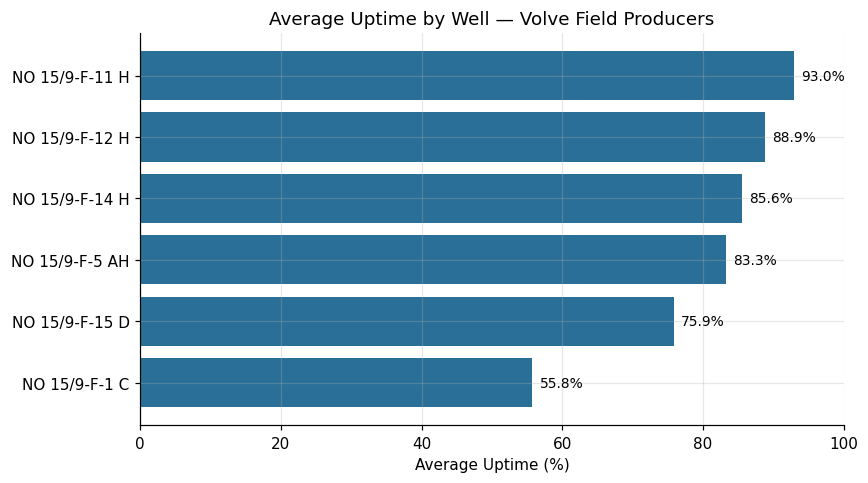

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = uptime_summary.index
bars = ax.barh(order, uptime_summary['avg_uptime_pct'], color='#2a6f97')
ax.set_xlabel('Average Uptime (%)')
ax.set_title('Average Uptime by Well — Volve Field Producers')
ax.set_xlim(0, 100)
ax.invert_yaxis()
for bar, val in zip(bars, uptime_summary['avg_uptime_pct']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/01_avg_uptime_by_well.png', dpi=150, bbox_inches='tight')
plt.show()

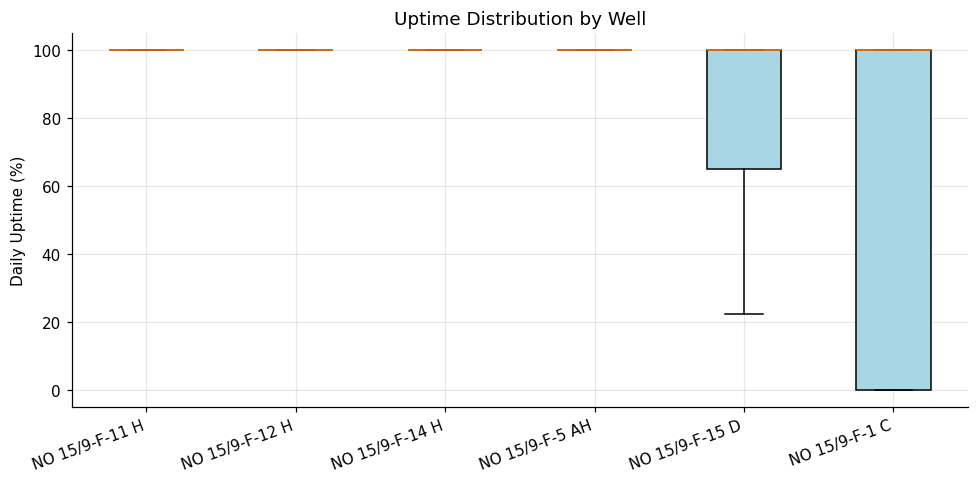

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
data_by_well = [clean.loc[clean['WELL_BORE_CODE'] == w, 'UPTIME_PCT'] for w in order]
bp = ax.boxplot(data_by_well, tick_labels=order, vert=True, patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('#a9d6e5')
ax.set_ylabel('Daily Uptime (%)')
ax.set_title('Uptime Distribution by Well')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../figures/02_uptime_distribution_by_well.png', dpi=150, bbox_inches='tight')
plt.show()

**Which wells operate most consistently?** `NO 15/9-F-11 H` (93.0% avg uptime) and
`NO 15/9-F-12 H` (88.9%) are the most consistent producers, each fully shut in on well under
10% of their producing days.

**Which wells lose the most operating time (as a percentage)?** `NO 15/9-F-1 C` stands out —
55.8% average uptime and full shutdown on 41.3% of its producing days, by far the least
reliable well in the field on a *percentage* basis. `NO 15/9-F-15 D` is second-worst at 75.9%
average uptime.

### Production Engineering Interpretation
Uptime percentage ranks wells by *reliability*, not by *scale* — `F-1 C` is the field's least
reliable well by a wide margin, which is exactly the kind of well a production engineer would
flag for an uptime/reliability review. But percentage uptime alone doesn't say how much oil
that unreliability actually costs the field, because it ignores the well's production rate.
That's the gap Sections 5-6 close.

## 5. Downtime Analysis

**Downtime Hours = 24 − `ON_STREAM_HRS`**

Uptime percentage treats every well the same regardless of how long it has been on
production. Downtime hours, summed over each well's full history, shows the absolute scale
of lost operating time — which is what actually drives lost barrels.

In [8]:
downtime_summary = clean.groupby('WELL_BORE_CODE').agg(
    total_downtime_hrs=('DOWNTIME_HRS', 'sum'),
    avg_downtime_hrs_per_day=('DOWNTIME_HRS', 'mean'),
    days=('DATEPRD', 'count'),
).sort_values('total_downtime_hrs', ascending=False)
downtime_summary['total_downtime_days_equiv'] = (downtime_summary['total_downtime_hrs'] / 24)

print(f"Field-wide total downtime: {clean['DOWNTIME_HRS'].sum():,.0f} hours "
      f"({clean['DOWNTIME_HRS'].sum()/24:,.0f} well-days-equivalent)")
print()
downtime_summary.round(1)

Field-wide total downtime: 34,796 hours (1,450 well-days-equivalent)



,total_downtime_hrs,avg_downtime_hrs_per_day,days,total_downtime_days_equiv
WELL_BORE_CODE,,,,
NO 15/9-F-14 H,10574.1,3.5,3056,440.6
NO 15/9-F-12 H,8143.9,2.7,3056,339.3
NO 15/9-F-1 C,7897.5,10.6,744,329.1
NO 15/9-F-15 D,5647.2,5.8,978,235.3
NO 15/9-F-11 H,1955.1,1.7,1165,81.5
NO 15/9-F-5 AH,578.7,4.0,144,24.1


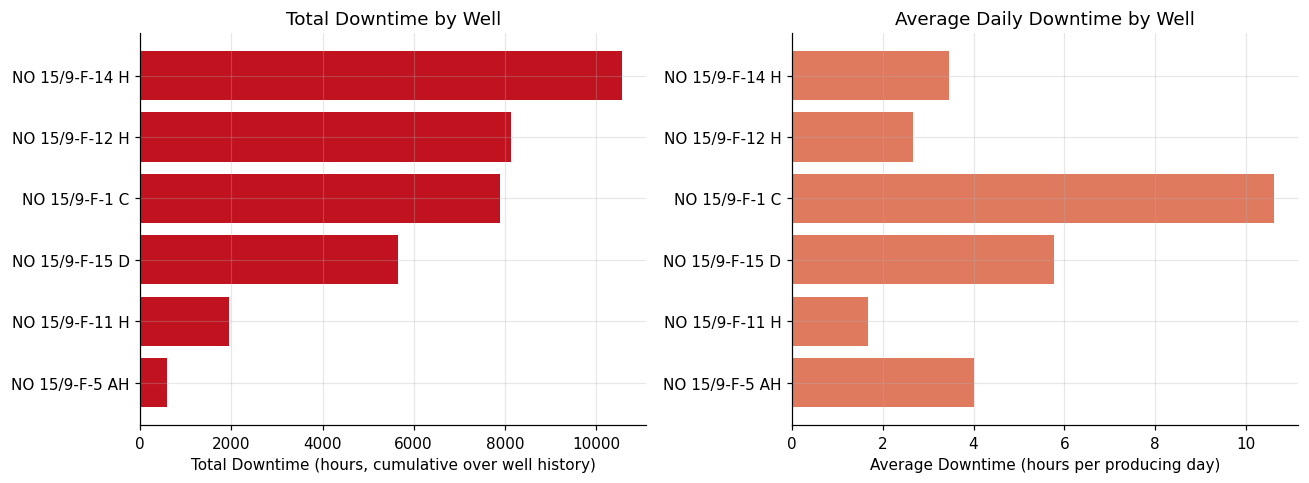

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order_dt = downtime_summary.index
axes[0].barh(order_dt, downtime_summary['total_downtime_hrs'], color='#c1121f')
axes[0].set_xlabel('Total Downtime (hours, cumulative over well history)')
axes[0].set_title('Total Downtime by Well')
axes[0].invert_yaxis()

axes[1].barh(order_dt, downtime_summary['avg_downtime_hrs_per_day'], color='#e07a5f')
axes[1].set_xlabel('Average Downtime (hours per producing day)')
axes[1].set_title('Average Daily Downtime by Well')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../figures/03_downtime_by_well.png', dpi=150, bbox_inches='tight')
plt.show()

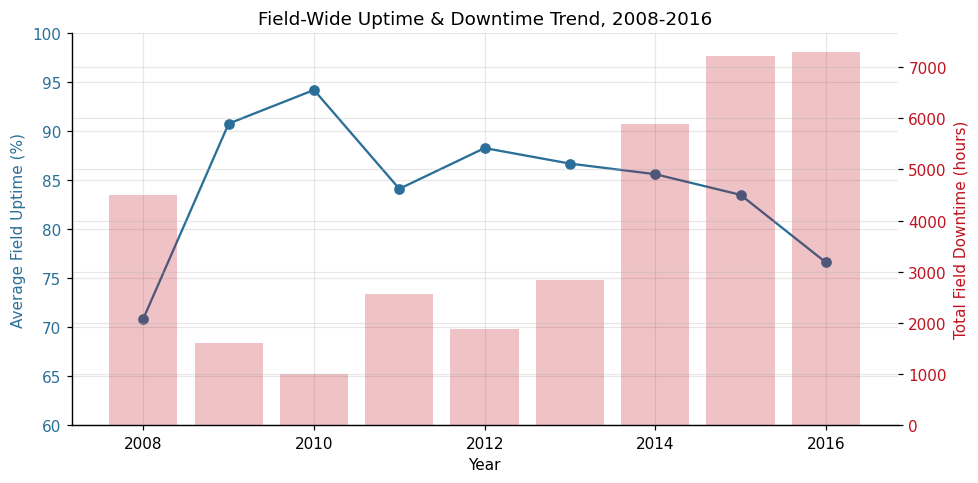

In [10]:
yearly = clean.groupby('YEAR').agg(
    avg_uptime_pct=('UPTIME_PCT', 'mean'),
    total_downtime_hrs=('DOWNTIME_HRS', 'sum'),
)

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(yearly.index, yearly['avg_uptime_pct'], marker='o', color='#2a6f97', label='Avg uptime %')
ax1.set_ylabel('Average Field Uptime (%)', color='#2a6f97')
ax1.set_ylim(60, 100)
ax1.set_xlabel('Year')
ax1.tick_params(axis='y', labelcolor='#2a6f97')

ax2 = ax1.twinx()
ax2.bar(yearly.index, yearly['total_downtime_hrs'], alpha=0.25, color='#c1121f', label='Total downtime hrs')
ax2.set_ylabel('Total Field Downtime (hours)', color='#c1121f')
ax2.tick_params(axis='y', labelcolor='#c1121f')

ax1.set_title('Field-Wide Uptime & Downtime Trend, 2008-2016')
fig.tight_layout()
plt.savefig('../figures/04_downtime_trend_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

**Which wells experience the highest downtime (absolute)?** `NO 15/9-F-14 H` (10,574 hours,
~441 well-days) and `NO 15/9-F-12 H` (8,144 hours, ~339 well-days) have accumulated by far the
most downtime in the field — but note this is because they have also been on production the
longest (3,056 days each), not because they are the least reliable day to day (Section 4
showed they actually have above-average uptime %). `NO 15/9-F-1 C` has the highest *average
daily* downtime (10.6 hrs/day) of any well, consistent with its poor uptime percentage.

**Downtime trend over time.** Field-wide uptime was volatile in the first two years (70.9% in
2008, recovering to 94.2% by 2010 as the field ramped up), stayed in a healthy 84-90% band
from 2011-2013, and then **downtime rose steadily from 2014 onward** — average uptime fell
to 83.5% in 2015 and 76.6% in 2016, with total field downtime hours in 2016 more than seven
times higher than in 2010. This decline coincides with the field's later-life maturity and
warrants flagging, though this dataset alone cannot say whether it reflects reservoir decline,
aging equipment, or a shift in operating strategy.

**Which wells require operational attention?** By *total* downtime hours, `F-14 H` and `F-12
H` top the list, but only because of their long history. By *rate* of downtime, `F-1 C` is the
clear outlier and the well most consistent with a genuine reliability problem.

### Production Engineering Interpretation
Total downtime hours and average daily downtime tell two different stories, and a production
engineer needs both: total hours identify where the field's cumulative lost-time budget has
gone (useful for a maintenance/workover business case), while the daily rate identifies which
well is *currently* behaving unreliably (useful for triggering an immediate investigation).
The late-field downtime increase (2014-2016) is a field-level signal worth escalating on its
own — it suggests something changed in either well condition or operating philosophy in the
field's later years, independent of any single well's behavior.

## 6. Production Loss Estimation

**Potential Production Rate (bbl/hr) = `BORE_OIL_VOL` / `ON_STREAM_HRS`**
**Estimated Lost Oil (bbl) = Potential Production Rate × (24 − `ON_STREAM_HRS`)**

This uses each well-day's own observed rate to estimate what additional oil *might* have been
produced during that day's downtime hours, had the well flowed at the same rate for the rest
of the day. **This is an estimate, not a measured or actual loss** — it assumes the well's
rate would have stayed constant, which the data cannot confirm. Only rows with
`ON_STREAM_HRS > 0` are used (the flagged zero-hours anomaly from Section 3 is excluded, since
the rate is undefined at zero hours).

In [11]:
rate_calc = clean[clean['ON_STREAM_HRS'] > 0].copy()
rate_calc['POTENTIAL_RATE_BBL_HR'] = rate_calc['BORE_OIL_VOL'] / rate_calc['ON_STREAM_HRS']
rate_calc['EST_LOST_OIL_BBL'] = rate_calc['POTENTIAL_RATE_BBL_HR'] * (24 - rate_calc['ON_STREAM_HRS'])

loss_summary = rate_calc.groupby('WELL_BORE_CODE').agg(
    total_est_lost_oil_bbl=('EST_LOST_OIL_BBL', 'sum'),
    total_actual_oil_bbl=('BORE_OIL_VOL', 'sum'),
).sort_values('total_est_lost_oil_bbl', ascending=False)
loss_summary['est_loss_as_pct_of_actual'] = (
    loss_summary['total_est_lost_oil_bbl'] / loss_summary['total_actual_oil_bbl'] * 100
).round(1)

loss_summary.round(0)

,total_est_lost_oil_bbl,total_actual_oil_bbl,est_loss_as_pct_of_actual
WELL_BORE_CODE,,,
NO 15/9-F-12 H,183317.0,4579610.0,4.0
NO 15/9-F-14 H,167265.0,3942233.0,4.0
NO 15/9-F-11 H,32130.0,1146823.0,3.0
NO 15/9-F-15 D,5873.0,148519.0,4.0
NO 15/9-F-1 C,4187.0,177187.0,2.0
NO 15/9-F-5 AH,178.0,38433.0,0.0


**A methodological caveat worth stating plainly.** The same-day rate used above is itself
depressed on days when the well was choked back or only partially online — so on a well's
worst downtime days, this method uses a *suppressed* rate to estimate the loss for that same
day, which tends to **understate** the true opportunity lost on exactly the days it matters
most. It's also numerically unstable at very low `ON_STREAM_HRS` (a well that flows for only a
few minutes can show an extreme, non-representative implied hourly rate). We check both
issues directly:

In [12]:
low_hr = rate_calc[rate_calc['ON_STREAM_HRS'] < 2]
high_hr = rate_calc[rate_calc['ON_STREAM_HRS'] >= 2]

print(f"Well-days with ON_STREAM_HRS < 2 hrs: {len(low_hr)} of {len(rate_calc)} ({len(low_hr)/len(rate_calc)*100:.1f}%)")
print(f"  Mean implied rate at <2hr uptime:  {low_hr['POTENTIAL_RATE_BBL_HR'].mean():>8.1f} bbl/hr "
      f"(max {low_hr['POTENTIAL_RATE_BBL_HR'].max():.0f})")
print(f"  Mean implied rate at >=2hr uptime: {high_hr['POTENTIAL_RATE_BBL_HR'].mean():>8.1f} bbl/hr "
      f"(max {high_hr['POTENTIAL_RATE_BBL_HR'].max():.0f})")

Well-days with ON_STREAM_HRS < 2 hrs: 32 of 8011 (0.4%)
  Mean implied rate at <2hr uptime:      62.3 bbl/hr (max 1013)
  Mean implied rate at >=2hr uptime:     54.2 bbl/hr (max 300)


The wide swing between the two groups confirms same-day rate estimation is noisy exactly where
it matters most. **As a more robust cross-check**, we also estimate lost oil using each well's
own **benchmark rate** — the 75th percentile of its daily rate, computed only from that well's
*near-full-uptime* days (`ON_STREAM_HRS >= 20`). This represents "what this well is capable of
producing per hour when it's healthy and online," and avoids using a suppressed same-day rate
to estimate that same day's own loss.

In [13]:
near_full = rate_calc[rate_calc['ON_STREAM_HRS'] >= 20]
benchmark_rate = near_full.groupby('WELL_BORE_CODE')['POTENTIAL_RATE_BBL_HR'].quantile(0.75)
benchmark_rate.name = 'BENCHMARK_RATE_BBL_HR'

print("Well-level benchmark rate (bbl/hr):")
benchmark_rate.round(1)

Well-level benchmark rate (bbl/hr):


WELL_BORE_CODE
NO 15/9-F-1 C      23.5
NO 15/9-F-11 H     51.9
NO 15/9-F-12 H    120.0
NO 15/9-F-14 H     98.5
NO 15/9-F-15 D      9.6
NO 15/9-F-5 AH     13.9
Name: BENCHMARK_RATE_BBL_HR, dtype: float64

In [14]:
clean_b = clean.merge(benchmark_rate, left_on='WELL_BORE_CODE', right_index=True, how='left')
clean_b['EST_LOST_OIL_BENCHMARK_BBL'] = clean_b['BENCHMARK_RATE_BBL_HR'] * clean_b['DOWNTIME_HRS']

loss_benchmark = clean_b.groupby('WELL_BORE_CODE')['EST_LOST_OIL_BENCHMARK_BBL'].sum().sort_values(ascending=False)

comparison = pd.DataFrame({
    'same_day_rate_method_bbl': loss_summary['total_est_lost_oil_bbl'],
    'benchmark_rate_method_bbl': loss_benchmark,
}).sort_values('benchmark_rate_method_bbl', ascending=False)

total_field_oil = clean['BORE_OIL_VOL'].sum()
print(f"Total field oil produced: {total_field_oil:,.0f} bbl")
print(f"Total estimated lost oil (benchmark method): {loss_benchmark.sum():,.0f} bbl "
      f"({loss_benchmark.sum()/total_field_oil*100:.1f}% of actual field production)")
print()
comparison.round(0)

Total field oil produced: 10,033,831 bbl
Total estimated lost oil (benchmark method): 2,367,730 bbl (23.6% of actual field production)



,same_day_rate_method_bbl,benchmark_rate_method_bbl
WELL_BORE_CODE,,
NO 15/9-F-14 H,167265.0,1041380.0
NO 15/9-F-12 H,183317.0,977494.0
NO 15/9-F-1 C,4187.0,185367.0
NO 15/9-F-11 H,32130.0,101458.0
NO 15/9-F-15 D,5873.0,53978.0
NO 15/9-F-5 AH,178.0,8053.0


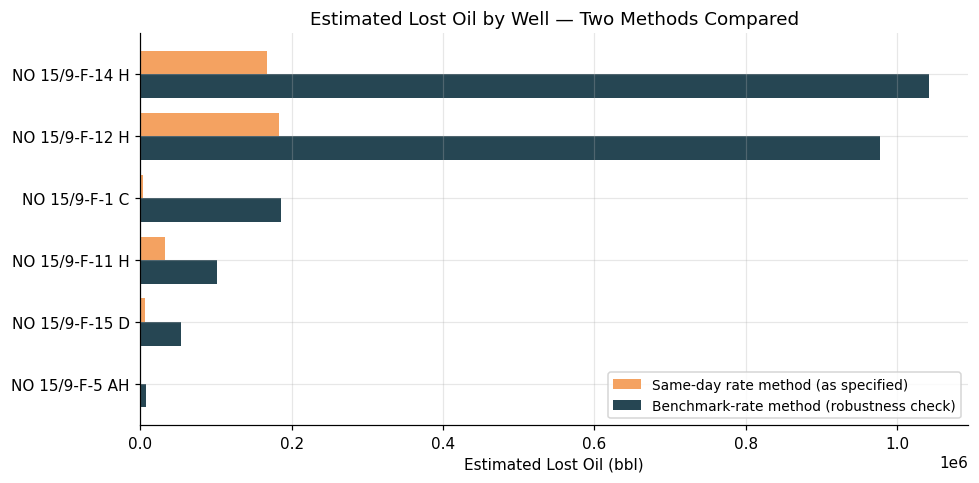

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(comparison))
width = 0.38
ax.barh(x - width/2, comparison['same_day_rate_method_bbl'], height=width,
        label='Same-day rate method (as specified)', color='#f4a261')
ax.barh(x + width/2, comparison['benchmark_rate_method_bbl'], height=width,
        label='Benchmark-rate method (robustness check)', color='#264653')
ax.set_yticks(x)
ax.set_yticklabels(comparison.index)
ax.set_xlabel('Estimated Lost Oil (bbl)')
ax.set_title('Estimated Lost Oil by Well — Two Methods Compared')
ax.invert_yaxis()
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/05_estimated_lost_oil_by_well.png', dpi=150, bbox_inches='tight')
plt.show()

**Which wells have the highest estimated production opportunity loss?** Both methods agree on
the ranking: `NO 15/9-F-14 H` and `NO 15/9-F-12 H` carry the largest estimated lost-oil
volumes by a wide margin (benchmark method: ~1.04M bbl and ~0.98M bbl respectively — together
over 85% of the field's total estimated loss), simply because they are the field's two
highest-rate wells, so even modest downtime translates into large absolute barrels. The
benchmark method estimates total field-wide lost opportunity at roughly 2.37M bbl, about 24%
of actual field production — a materially larger figure than the same-day method's estimate,
consistent with the understatement bias flagged above.

**Which wells should be reviewed first (by lost-opportunity volume)?** `F-14 H` and `F-12 H`,
unambiguously — not because they are unreliable (Section 4 showed above-field-average uptime
on both), but because their scale means even routine downtime is expensive in absolute terms.

### Production Engineering Interpretation
Two defensible methods were used deliberately, because a single number here would be
misleadingly precise for what is fundamentally an estimate. What both agree on — and what
actually matters for prioritization — is the **ranking**: the field's two largest producers
are also its two largest production-loss opportunities, even though neither is the field's
least reliable well. That distinction (loss ranking vs. reliability ranking) is the single
most important insight of this project, and it directly motivates the opportunity-matrix
framework in Section 8.

## 7. Production Efficiency Analysis

**A note on the literal formula.** The project brief defines Production Efficiency as
`Actual Production / Potential Production`. If "Potential Production" is built from the
*same-day* rate (`Potential Rate × 24`, using the rate from Section 6), this KPI is
**mathematically identical to uptime percentage** — it reduces algebraically to
`ON_STREAM_HRS / 24`, adding no new information despite looking like a distinct metric. We
verify this directly rather than asserting it:

In [16]:
naive_efficiency = rate_calc['BORE_OIL_VOL'] / (rate_calc['POTENTIAL_RATE_BBL_HR'] * 24)
naive_uptime_fraction = rate_calc['ON_STREAM_HRS'] / 24
max_diff = (naive_efficiency - naive_uptime_fraction).abs().max()

print(f"Max |same-day 'efficiency' - uptime fraction| across {len(rate_calc):,} well-days: {max_diff:.2e}")
print("-> Confirmed identical (within floating-point rounding). This formulation would be")
print("   a redundant KPI, so we use the benchmark-rate potential instead.")

Max |same-day 'efficiency' - uptime fraction| across 8,011 well-days: 2.22e-16
-> Confirmed identical (within floating-point rounding). This formulation would be
   a redundant KPI, so we use the benchmark-rate potential instead.


Instead, **Production Efficiency here is computed against each well's own benchmark rate**
(from Section 6) — this captures whether a well, *while it was flowing*, produced at a rate
close to its own healthy-day rate, which is a genuinely different question from "was it
online."

**Production Efficiency % = `BORE_OIL_VOL` / (Benchmark Rate × `ON_STREAM_HRS`) × 100**

(computed only on days the well was actually online, `ON_STREAM_HRS > 0`)

In [17]:
clean_b['POTENTIAL_OIL_BBL'] = clean_b['BENCHMARK_RATE_BBL_HR'] * clean_b['ON_STREAM_HRS']
online = clean_b[clean_b['ON_STREAM_HRS'] > 0].copy()
online['EFFICIENCY_PCT'] = (online['BORE_OIL_VOL'] / online['POTENTIAL_OIL_BBL'] * 100)

efficiency_summary = online.groupby('WELL_BORE_CODE').agg(
    avg_efficiency_pct=('EFFICIENCY_PCT', 'mean'),
    median_efficiency_pct=('EFFICIENCY_PCT', 'median'),
).sort_values('avg_efficiency_pct', ascending=False)

efficiency_summary.round(1)

,avg_efficiency_pct,median_efficiency_pct
WELL_BORE_CODE,,
NO 15/9-F-5 AH,95.5,94.5
NO 15/9-F-15 D,87.5,84.0
NO 15/9-F-11 H,84.4,88.2
NO 15/9-F-1 C,73.7,60.8
NO 15/9-F-14 H,63.8,45.6
NO 15/9-F-12 H,58.3,28.8


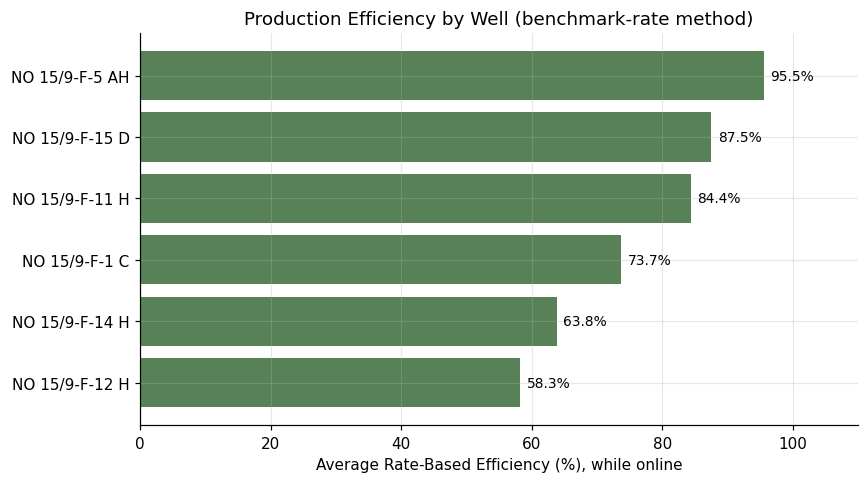

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order_e = efficiency_summary.index
bars = ax.barh(order_e, efficiency_summary['avg_efficiency_pct'], color='#588157')
ax.set_xlabel('Average Rate-Based Efficiency (%), while online')
ax.set_title('Production Efficiency by Well (benchmark-rate method)')
ax.set_xlim(0, 110)
ax.invert_yaxis()
for bar, val in zip(bars, efficiency_summary['avg_efficiency_pct']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/06_efficiency_by_well.png', dpi=150, bbox_inches='tight')
plt.show()

**Which wells convert on-stream time into production most effectively?** `NO 15/9-F-5 AH`
(95.5%) and `NO 15/9-F-15 D` (87.5%) are the most rate-efficient wells while online — when
they're flowing, they flow close to their own best-observed rate.

**Which wells may require operational review on a rate basis?** `NO 15/9-F-12 H` (58.3% avg,
but a **median of only 28.8%**) and `NO 15/9-F-14 H` (63.8% avg, median 45.6%) stand out — the
large gap between mean and median for both wells indicates their efficiency distribution is
skewed, with a meaningful share of producing days running well below their own benchmark rate
even while technically "on stream." This is a materially different finding from the uptime
analysis: these are the field's two most *reliable* wells by uptime, yet also its two least
*rate-efficient* wells while flowing.

### Production Engineering Interpretation
This is the section where catching the algebraic-identity trap matters most: a naive
implementation of the brief's formula would have reproduced Section 4's uptime ranking under a
different name and called it a new insight — exactly the kind of interview trap the project
brief warns against. The benchmark-rate version surfaces a genuinely new signal: `F-12 H` and
`F-14 H` are online often, but when online, a meaningful share of their producing days fall
well short of their own demonstrated capability. That combination — high uptime, inconsistent
rate — is a distinct operational pattern from low uptime, and it points toward a different
investigation (choke management, artificial lift performance, or facility constraints) than a
pure downtime review would.

## 8. Opportunity Matrix — Well Prioritization Framework

We combine **production level** (average daily oil) and **downtime level** (average daily
downtime hours) into a four-quadrant prioritization framework, splitting each dimension at its
field median (a natural, non-arbitrary threshold with only 6 wells in the field):

| | Low Downtime | High Downtime |
|---|---|---|
| **High Production** | Monitor | **Highest Priority** |
| **Low Production** | Low Priority | Medium Priority |

In [19]:
well_level = clean_b.groupby('WELL_BORE_CODE').agg(
    total_oil_bbl=('BORE_OIL_VOL', 'sum'),
    avg_downtime_hrs_per_day=('DOWNTIME_HRS', 'mean'),
    avg_uptime_pct=('UPTIME_PCT', 'mean'),
    days=('DATEPRD', 'count'),
)
well_level['avg_daily_oil_bbl'] = well_level['total_oil_bbl'] / well_level['days']
well_level['est_lost_oil_bbl'] = loss_benchmark

prod_median = well_level['avg_daily_oil_bbl'].median()
downtime_median = well_level['avg_downtime_hrs_per_day'].median()

def classify(row):
    high_prod = row['avg_daily_oil_bbl'] >= prod_median
    high_down = row['avg_downtime_hrs_per_day'] >= downtime_median
    if high_prod and high_down:
        return 'Highest Priority'
    if high_prod and not high_down:
        return 'Monitor'
    if not high_prod and high_down:
        return 'Medium Priority'
    return 'Low Priority'

well_level['priority'] = well_level.apply(classify, axis=1)
well_level = well_level.sort_values('est_lost_oil_bbl', ascending=False)

print(f"Field median avg daily oil:      {prod_median:.1f} bbl/day")
print(f"Field median avg daily downtime: {downtime_median:.2f} hrs/day")
print()
well_level[['avg_daily_oil_bbl', 'avg_downtime_hrs_per_day', 'avg_uptime_pct',
            'est_lost_oil_bbl', 'priority']].round(1)

Field median avg daily oil:      626.1 bbl/day
Field median avg daily downtime: 3.74 hrs/day



,avg_daily_oil_bbl,avg_downtime_hrs_per_day,avg_uptime_pct,est_lost_oil_bbl,priority
WELL_BORE_CODE,,,,,
NO 15/9-F-14 H,1290.0,3.5,85.6,1041380.3,Monitor
NO 15/9-F-12 H,1498.6,2.7,88.9,977494.3,Monitor
NO 15/9-F-1 C,238.2,10.6,55.8,185366.7,Medium Priority
NO 15/9-F-11 H,985.3,1.7,93.0,101457.9,Monitor
NO 15/9-F-15 D,151.9,5.8,75.9,53977.5,Medium Priority
NO 15/9-F-5 AH,266.9,4.0,83.3,8053.3,Medium Priority


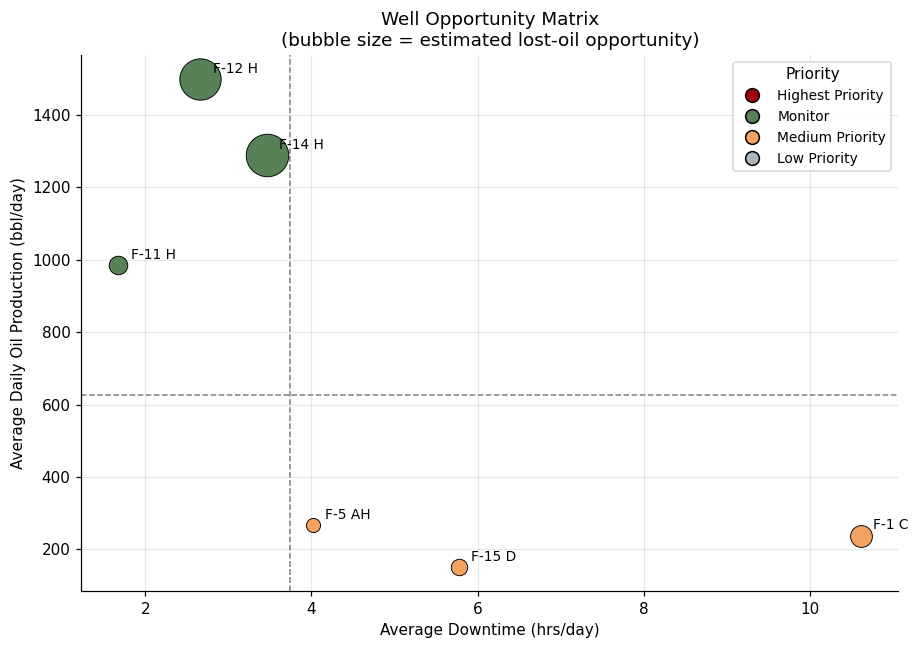

In [20]:
priority_colors = {
    'Highest Priority': '#9d0208',
    'Monitor': '#588157',
    'Medium Priority': '#f4a261',
    'Low Priority': '#adb5bd',
}

fig, ax = plt.subplots(figsize=(8.5, 6))
for well, row in well_level.iterrows():
    ax.scatter(row['avg_downtime_hrs_per_day'], row['avg_daily_oil_bbl'],
               s=row['est_lost_oil_bbl'] / 1500 + 80,
               color=priority_colors[row['priority']], edgecolor='black', linewidth=0.6, zorder=3)
    ax.annotate(well.replace('NO 15/9-', ''),
                (row['avg_downtime_hrs_per_day'], row['avg_daily_oil_bbl']),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.axvline(downtime_median, color='grey', linestyle='--', linewidth=1)
ax.axhline(prod_median, color='grey', linestyle='--', linewidth=1)
ax.set_xlabel('Average Downtime (hrs/day)')
ax.set_ylabel('Average Daily Oil Production (bbl/day)')
ax.set_title('Well Opportunity Matrix\n(bubble size = estimated lost-oil opportunity)')

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markeredgecolor='black',
                   markersize=9, label=p) for p, c in priority_colors.items()]
ax.legend(handles=handles, loc='upper right', fontsize=9, title='Priority')

plt.tight_layout()
plt.savefig('../figures/07_opportunity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Which wells offer the greatest production recovery opportunity?** The quadrant split
produces a clean but noteworthy result: **no well falls into the "Highest Priority" quadrant**
(high production AND high downtime) or the "Low Priority" quadrant (low production AND low
downtime) — the field splits cleanly into its two biggest producers (`F-12 H`, `F-14 H`,
both classified `Monitor` — high production, below-median downtime) and its four smaller
producers (all `Medium Priority` — below-median production, above-median downtime).

This is a real and important limitation of the quadrant framework to state plainly: **a simple
median-split matrix ranks `F-12 H` and `F-14 H` as lower urgency ("Monitor") than the four
smaller wells, even though Section 6 showed those same two wells hold over 85% of the field's
total estimated lost-oil opportunity.** The quadrant logic rewards *relative* downtime rate
and misses *absolute* opportunity — a well can look fine on a percentage basis and still be
the single biggest lever in the field simply because of its scale.

### Production Engineering Interpretation
A production engineer wouldn't use the quadrant label alone to set priorities — the bubble
size (estimated lost-oil volume) in the chart above is what actually drives the recommended
order of investigation, and it's why it's plotted alongside the quadrant color. The
disagreement between the "Monitor" label and the largest lost-oil bubbles on `F-12 H` and
`F-14 H` is itself a useful finding: it shows the value of pairing a relative-rate metric
(the quadrant) with an absolute-volume metric (the bubble size) rather than trusting either
one alone. In an interview, this is the moment to say explicitly: *the framework's own output
disagreed with the volume-based ranking, so the volume-based ranking wins for prioritization,
and that disagreement should be reported rather than hidden.*

## 9. Engineering Recommendations

Recommendations are ranked by **estimated lost-oil opportunity** (Section 6), with uptime,
downtime rate, and efficiency findings used to suggest *what kind* of review each well
warrants. Consistent with the project scope, these are recommendations to **investigate
further**, not prescriptions for a specific field intervention.

**`NO 15/9-F-14 H`** — largest estimated lost-oil opportunity in the field (~1.04M bbl) despite
above-field-average uptime (85.6%) and the lowest rate-efficiency in the field (63.8% avg,
45.6% median). This well should be considered for further **rate-efficiency and choke/lift
performance review** — the pattern (online often, but frequently below its own benchmark rate)
points away from a pure downtime problem.

**`NO 15/9-F-12 H`** — second-largest estimated lost-oil opportunity (~0.98M bbl), similar
profile to `F-14 H`: strong uptime (88.9%) but the field's lowest efficiency (58.3% avg, 28.8%
median). This well may warrant **operational surveillance** focused on why on-stream
production frequently falls short of its own demonstrated best-rate days.

**`NO 15/9-F-1 C`** — the field's clear reliability outlier: 55.8% average uptime, full
shutdown on 41.3% of its producing days, and the highest average daily downtime (10.6
hrs/day) of any well. This well should be considered for a **downtime-cause investigation** —
its loss pattern is the opposite of `F-12/14 H`: a downtime problem more than a rate problem.

**`NO 15/9-F-11 H`** — the field's most reliable well by uptime (93.0%) and third-highest
lost-oil volume (~0.10M bbl) simply due to scale; efficiency (84.4% avg) is solid but not
best-in-field. Lower priority than the above three; a **routine surveillance cadence** is
reasonable rather than a dedicated review.

**`NO 15/9-F-15 D` and `NO 15/9-F-5 AH`** — both low-volume wells with comparatively minor
estimated lost-oil opportunity (~54K bbl and ~8K bbl respectively) despite `F-15 D` showing
elevated downtime (21.4% of days fully shut in). Given the small absolute barrels at stake,
these are reasonable candidates for a **scheduled, lower-frequency operational review** rather
than immediate escalation.

### Production Engineering Interpretation
The recommendation order deliberately does not match either the pure uptime ranking or the
pure downtime ranking — it's built from the estimated-loss ranking because that's the metric
that best reflects "how many barrels are actually at stake," which is what a production
engineering team ultimately has to justify spending review time and budget against.

## 10. Executive Summary

**Scope.** This analysis screened daily production data (2008-2016) for 6 oil-producer wells
in the Volve field — 9,143 well-days after cleaning — to identify where production is being
lost to downtime and which wells should be prioritized for production-recovery review.

**Major findings**

- Field-wide average uptime across the analysis period was **84.1%**, with a total of
  **~34,800 downtime hours** (~1,450 well-days-equivalent) recorded across all producers.
- **Highest downtime wells:** `F-14 H` and `F-12 H` by total hours (each with the longest
  producing history in the field); `F-1 C` by rate (10.6 hrs/day average, 41.3% of days fully
  shut in) — the field's clear reliability outlier.
- **Highest estimated production-loss wells:** `F-14 H` (~1.04M bbl) and `F-12 H` (~0.98M
  bbl), together accounting for over 85% of the field's total estimated lost-oil opportunity
  (~2.37M bbl field-wide, ~24% of actual field production) — driven by scale and rate
  inconsistency rather than poor uptime.
- **Highest opportunity wells:** `F-14 H` and `F-12 H` again lead once the analysis is
  weighted by absolute barrels, even though a simple relative-rate quadrant framework
  classified both as lower-urgency "Monitor" wells — a disagreement this project surfaces and
  resolves in favor of the volume-based ranking (Section 8).
- **Operational insight:** the field shows two distinct underperformance patterns that require
  different follow-up — a **downtime/reliability pattern** (`F-1 C`) and a **rate-efficiency
  pattern despite good uptime** (`F-12 H`, `F-14 H`). Treating both as "downtime problems"
  would misdirect engineering attention on the wells that matter most.
- Field-wide downtime **increased in the later years of production** (2014-2016 vs. 2010-2013),
  a trend worth tracking independently of any single well.

**Limitations**

- Estimated lost-oil figures are **estimates built on assumed constant rates**, not measured
  or verified losses — two methods were used and they materially disagree in magnitude (though
  not in ranking), which should be reported alongside any figure quoted from this analysis.
- The dataset cannot distinguish *planned* downtime (tests, scheduled maintenance) from
  *unplanned* downtime (failures, reservoir issues) — every downtime hour here is treated
  equivalently, which likely overstates the "recoverable" portion of total downtime.
- With only 6 wells, the opportunity-matrix quadrant framework is illustrative rather than
  statistically robust; it is best used alongside the absolute lost-oil ranking, not in place
  of it (Section 8).
- Pressure, choke, and temperature data exist in the source dataset but were intentionally
  excluded from this screening-level analysis; they would be the natural next step for
  root-cause diagnosis on any well flagged here.

**Recommended next steps**

1. Prioritize an operational review of `F-14 H` and `F-12 H` focused on rate-efficiency
   (choke management, artificial lift performance) rather than uptime.
2. Investigate the underlying cause(s) of `F-1 C`'s downtime pattern specifically — its
   profile differs enough from the rest of the field to warrant a dedicated look.
3. Incorporate downhole pressure and choke-size data (excluded here by design) as the natural
   second-stage diagnostic for whichever wells are prioritized from this screening.
4. Revisit the field-wide downtime uptrend (2014-2016) as a standalone operations question,
   independent of individual well prioritization.